# Jupyter Notebook: Decision Trees

## Step 1: Install Required Libraries

First, ensure you have the necessary libraries installed. You can install them using the following command:

`pip install pandas numpy seaborn matplotlib scikit-learn`

In [71]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Step 2: Reading the data and data cleaning
Reading the training data

In [72]:
df = pd.read_csv(r'train.csv') # Replace by your path
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Determining how many missing values each column contains. 

In [73]:
column_names = df.columns
for column in column_names:
    missing_count = df[column].isnull().sum()
    total_count = len(df[column])
    missing_percentage = (missing_count / total_count) * 100
    print(f'{column} - {missing_count}, {missing_percentage:.2f}%')

PassengerId - 0, 0.00%
Survived - 0, 0.00%
Pclass - 0, 0.00%
Name - 0, 0.00%
Sex - 0, 0.00%
Age - 177, 19.87%
SibSp - 0, 0.00%
Parch - 0, 0.00%
Ticket - 0, 0.00%
Fare - 0, 0.00%
Cabin - 687, 77.10%
Embarked - 2, 0.22%


* Age has ~20% missing values. This will require handling.
* Cabin has ~77% missing values and might be excluded from analysis.
* Embarked has a small proportion of missing values. This will require handling.

Filling missing values for 'age' with the median. The median is used here instead of the mean because it is less affected by outliers. The 'age' column might have extreme values (very young or very old passengers), and the median provides a more robust measure.

In [74]:
df['Age'] = df['Age'].fillna(df['Age'].median())

Filling missing values for 'Embarked' with the mode.
The 'Embarked' column contains categorical data. Using the mode (most frequent value) ensures that the imputed value makes sense contextually.

In [75]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Dropping 'Cabin' due to a large number of missing values
The 'Cabin' column has too many missing values to be useful for analysis. Dropping it simplifies the dataset.

In [76]:
df = df.drop(columns=['Cabin'])

Let's make sure that there are no more missing values. 

In [77]:
column_names = df.columns
for column in column_names:
    missing_count = df[column].isnull().sum()
    total_count = len(df[column])
    missing_percentage = (missing_count / total_count) * 100
    print(f'{column} - {missing_count}, {missing_percentage:.2f}%')

PassengerId - 0, 0.00%
Survived - 0, 0.00%
Pclass - 0, 0.00%
Name - 0, 0.00%
Sex - 0, 0.00%
Age - 0, 0.00%
SibSp - 0, 0.00%
Parch - 0, 0.00%
Ticket - 0, 0.00%
Fare - 0, 0.00%
Embarked - 0, 0.00%


In [78]:
# Dropping the passengerId, Name, and Ticket
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

In [79]:
# Convert categorical to numeric
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

## Step 3: Separating the target value (Survived) from the rest 
Separating the features from the target

In [80]:
# Features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

## Step 4: Spliting the data 
Dividing the data into train and validation sets (Kaggle has already separated a test set) 

In [81]:
# Train-val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 5: Training the decision tree classifier
Defining the model and training the model. 

In [82]:
# Create and train the model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

# Step 6: Calculate the performance of the model
We are going to use some numerical metrics to calculate the performance of the algorithm

In [83]:

# Predictions
y_pred = model.predict(X_val)

# Evaluation
print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))

Accuracy: 0.7821229050279329

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.73      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179


Confusion Matrix:
 [[84 21]
 [18 56]]


# Step 7: Visualize the decision tree classifier

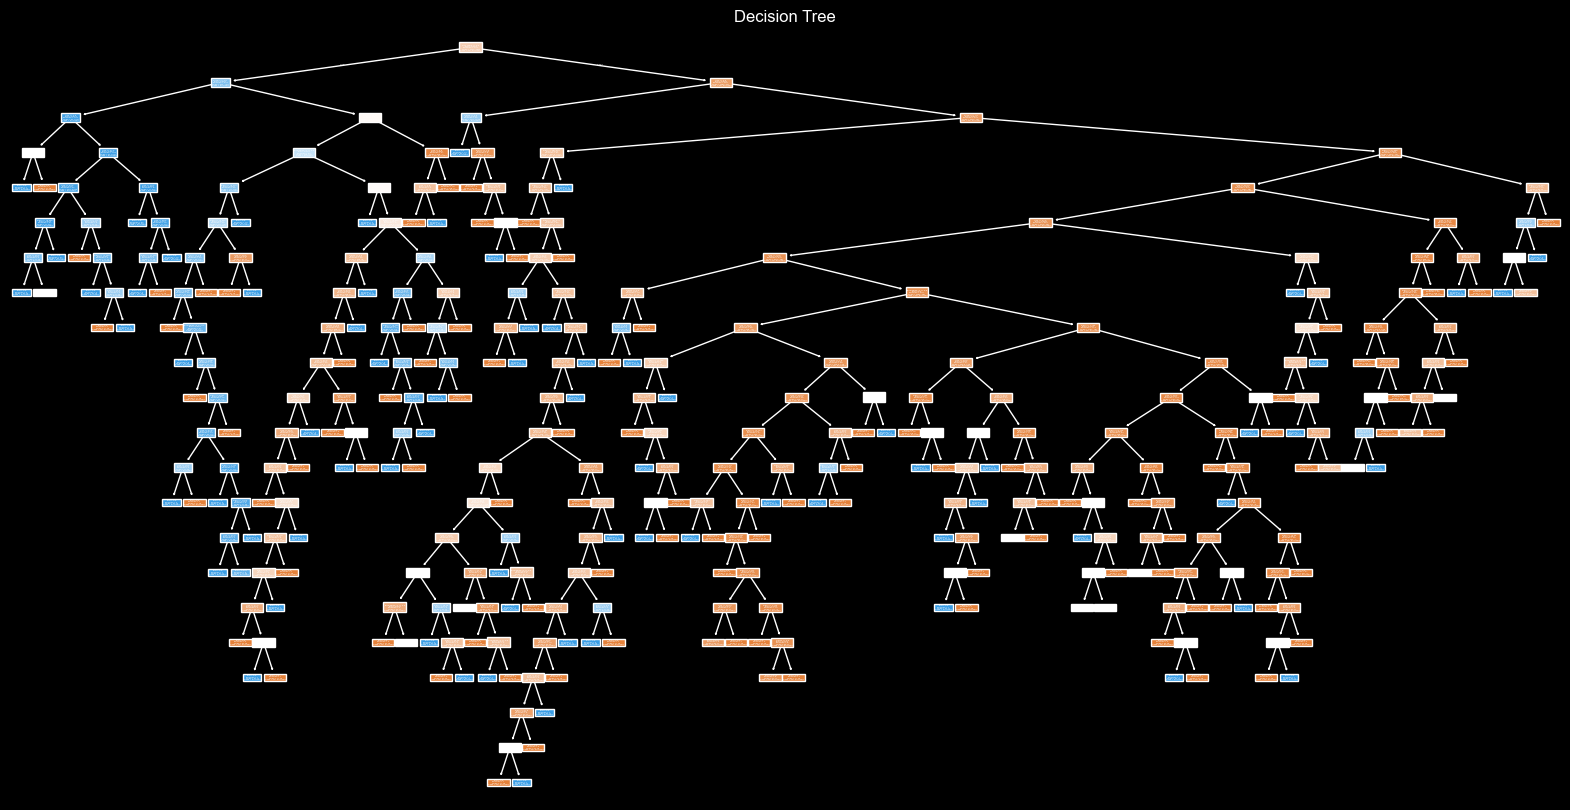

In [84]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=['Not Survived', 'Survived'])
plt.title("Decision Tree")
plt.show()

## Investigation tasks

**Task 1**: Explain how you can interpret a confusion matrix and interpret the confusion matrix obtained in step 6.

<span style="color:red">(1 mark)</span>

               precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.73      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179


Confusion Matrix:
 [[84 21]
 [18 56]]

The confusion matrix is can be interpreted via the first column/row (1,1) being the amount of positives being predicted as positive, the (1,2) spot means the amount of Negative being positive, (2,1) is the amount of negative being positive, (2,2) is the amount of negative being predicted negative.

**Task 2**: In machine learning, various metrics are used to evaluate the performance of classification algorithms. Two of the most commonly used are Accuracy and F1-Score.
Research and explain what each of these metrics represents, including their mathematical formulas. Then, discuss which metric is more appropriate when dealing with an imbalanced dataset (e.g., when the number of survivors and non-survivors is not equal, as in the Titanic dataset). Provide a clear justification for your choice.

<span style="color:red">(2 marks)</span>

Accuracy is the proportion of correct prediction out of all predictions, it is below:
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$
F1 Score is a metric that combines precision and recall score, scored between 0 and 1, being calculated from the below formula:
$$
F_1 = \frac{2 \cdot (\text{precision} \cdot \text{recall})}{\text{precision} + \text{recall}}
$$
In this case, the most correct data to pick is F1 score, as a model with high accuracy could be returning undesired predictions in a imbalanced data set, like always returning False.

**Task 3**: Calculate the Accuracy and F1-Score for both the training and validation datasets. Then, analyse and interpret the results, what do the metrics suggest about your model’s performance? Is there any evidence of overfitting or underfitting?

<span style="color:red">(2 marks)</span>

The model accuracy is 0.78, with it being good but not great, also alluding to it performing better on the majority class than the minority class. The f1 score is 0.81 on those whom did not survive, which is pretty good however it is 0.74 on those whom survived, therefore impling that there is evidence of overfitting.

**Task 4**: Train a new decision tree using only 'Sex_male', and 'Age' as features. Calculate and interpret the performance on training and validation. Compare the results to the previous model.

<span style="color:red">(2 marks)</span>

In [85]:
X = df[['Sex_male', 'Age']]
y = df['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

**Task 5**: Visualize new decision tree and interpret it. 

<span style="color:red">(1 mark)</span>

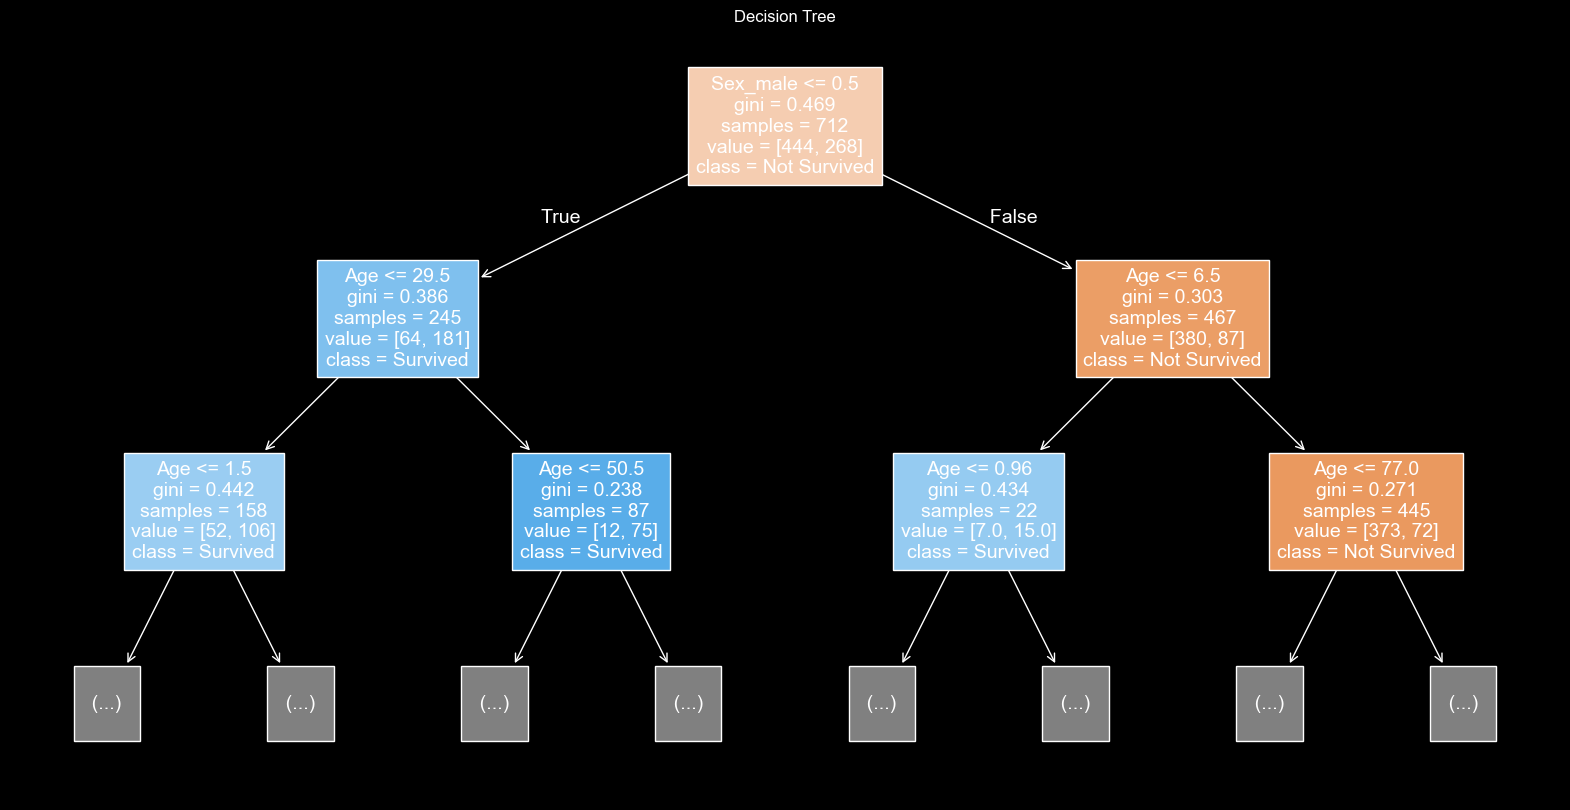

In [86]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, filled=True,max_depth=2, feature_names=X.columns, class_names=['Not Survived', 'Survived'])
plt.title("Decision Tree")
plt.show()

The decision tree works via classifying and splitting the data set up, the first question is the most important question, as seen above the question was in regards to its gender, asking whether it is male or female.

**Task 6**: When training a Decision Tree Classifier, several parameters can be adjusted to control the model’s complexity and improve its performance, particularly in addressing issues like overfitting and underfitting.

Using the [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html), choose three parameters of the DecisionTreeClassifier. For each parameter:

- Describe what it does

- Explain how changing its value could influence overfitting or underfitting in the model

<span style="color:red">(3 marks)</span>

<span style="color:red">Your answer goes here</span>

**Task 7**: Select a few different values for the three parameters you previously explored and train multiple Decision Tree models using these combinations. 

- Evaluate each model using a performance metric of your choice (e.g., Accuracy or F1-Score) on both the training and validation sets

- Compare the results across the different parameter settings

- Identify which combination of parameters provides the best overall performance


<span style="color:red">(4 marks)</span>


In [87]:
# Your answer goes here (Make one code cell per test)

**Bonus**: Use GridSearch and RandomSearch to find the best combination of parameters. 

<span style="color:red">(0.5 marks)</span>

**Bonus**: Try to improve the results as much as possible. Some ideas of things you could try:

- Testing which are the best features to train the algorithm
- Cross-validation
- Majority voting
- Other classification algorithms
- A combination of classification algorithms

<span style="color:red">(Up to 2 marks)</span>